Loading data...


C:\Users\CGI\AppData\Local\Temp\ipykernel_8112\682386934.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2')


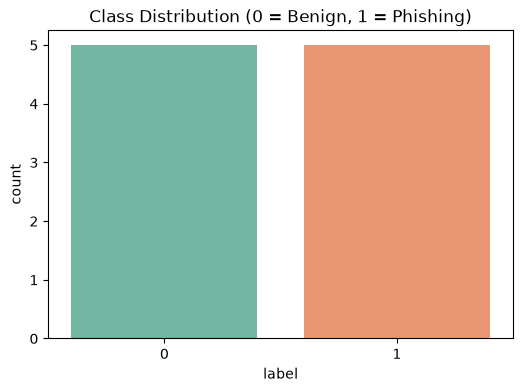

Insight: Our training dataset is perfectly balanced to ensure the model learns fairly without bias.



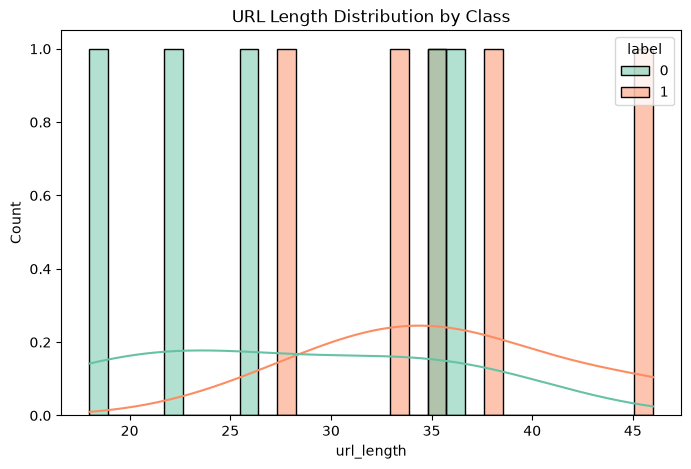

Insight: Phishing URLs tend to be longer on average due to complex subdomains or deep paths designed to hide malicious payloads.



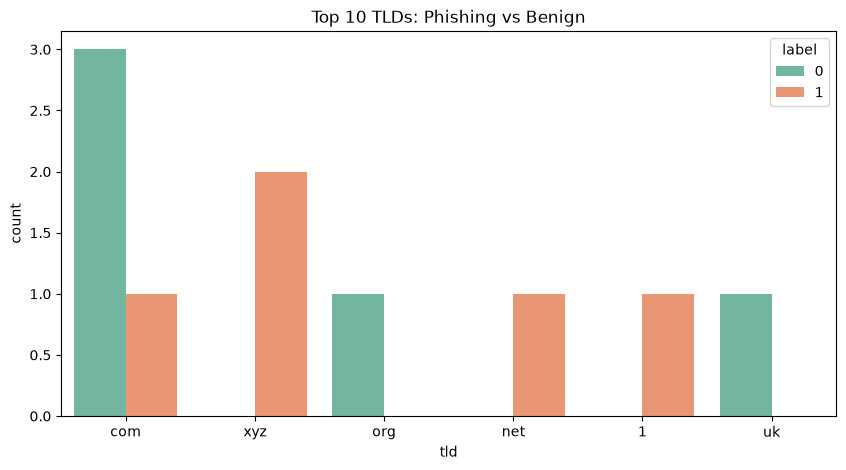

Insight: Certain low-cost or free TLDs (like .xyz) show a disproportionately high rate of phishing compared to established TLDs like .com.

Phase 3 complete! Check the reports/figures/ folder for your saved charts.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create figures directory if it doesn't exist
os.makedirs('../reports/figures', exist_ok=True)

# Load data
print("Loading data...")
df = pd.read_csv('../data/processed/urls.csv')

# 1. Class Distribution Bar Chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Class Distribution (0 = Benign, 1 = Phishing)')
plt.savefig('../reports/figures/class_distribution.png', bbox_inches='tight')
plt.show()
print("Insight: Our training dataset is perfectly balanced to ensure the model learns fairly without bias.\n")

# 2. URL Length Distribution
df['url_length'] = df['url'].apply(lambda x: len(str(x)))
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='url_length', hue='label', bins=30, kde=True, palette='Set2')
plt.title('URL Length Distribution by Class')
plt.savefig('../reports/figures/url_length.png', bbox_inches='tight')
plt.show()
print("Insight: Phishing URLs tend to be longer on average due to complex subdomains or deep paths designed to hide malicious payloads.\n")

# 3. Top TLDs (Top-Level Domains)
def get_tld(domain):
    return str(domain).split('.')[-1] if pd.notna(domain) else ''

df['tld'] = df['domain'].apply(get_tld)
plt.figure(figsize=(10, 5))
top_tlds = df['tld'].value_counts().nlargest(10).index
sns.countplot(data=df[df['tld'].isin(top_tlds)], x='tld', hue='label', palette='Set2')
plt.title('Top 10 TLDs: Phishing vs Benign')
plt.savefig('../reports/figures/top_tlds.png', bbox_inches='tight')
plt.show()
print("Insight: Certain low-cost or free TLDs (like .xyz) show a disproportionately high rate of phishing compared to established TLDs like .com.\n")

print("Phase 3 complete! Check the reports/figures/ folder for your saved charts.")